In [6]:
### Import Library

MACHINE_FC = 'C:/Users/franc/Box/ALAB Data Francis Cavanna/'
MACHINE_JA = '/Users/jra3859/Library/CloudStorage/Box-Box/ALAB Data/ALAB Data — Archive/ALAB Data Francis Cavanna/'
MACHINE = MACHINE_JA

import numpy as np # Generalized mathematical operations
import pandas as pd # For manipulating dataframes
import matplotlib.pyplot as plt# Generalized plotting
import os as os #For manipulating directory values

#Seaborn for making boxplots
import seaborn as sns # boxplots for fig 1e-f
import statannotations as sann # boxplots for fig 1e-f (might be defunct)
from statannotations.Annotator import Annotator # Automatic program for recognizing statistical significance.

# Change directory to master directory to make ease of use possible.
os.chdir(MACHINE_FC + '2021 Actomyosin Control/')

# List a directory master folder
base_folder = MACHINE_FC + '2021 Actomyosin Control/'


In [7]:
# Saved results for myosin activity rate found by running Nelder mead search algorithm on previous experiments. (mM/s)
kmy_result = [0.0013165274170419128, 0.001491050522094639, 0.001362683705508072, 0.004087037028677409, 0.006837348404687527, 
      0.002244136067481195, 0.0014282037724002716, 0.010320089042819447, 0.013701627679458817, 0.016491178626356184, 
      0.0013430940923084833, 0.00011723981525602056]

# Saved results for diffusion found by running Nelder mead search algorithm on previous experiments. (microns^2/s)
D_result = [95.48825528366228, 137.38858248492636, 161.26301525526256, 84.299068008207, 81.70746657749527, 206.07926426555423, 
     77.10989720963045, 134.19552029608442, 
     66.83111355341607, 223.58249258644562, 58.543961145226326, 139.18696870313545]

print("Diffusion mean is "+ str(np.mean(D_result)))
print("kmy_result mean is "+ str(np.mean(kmy_result)))

print("Diffusion standard deviation is "+ str(np.std(D_result)))
print("kmy_result standard deviation is "+ str(np.std(kmy_result)))



### Simulation parameters, or numbers I need to define to run the simulation:

#Define my pixel-micron conversion ratio
starter_microns = 1569.2971373332712 # We want our simulation to span this number of microns. 
starter = 75 # number of spaces desired in list, can vary.
starter_ratio = starter_microns/starter # Conversion ratio for distance per index, or (microns/index)

Diffusion mean is 122.13963378075384
kmy_result mean is 0.005061684681174165
Diffusion standard deviation is 51.99657385564526
kmy_result standard deviation is 0.005298664431929588


In [8]:
# Calculate catalytic rate for myosin activity constant from myosin activity rate (kmy)

# Each step of the simulation occurs within a box. The myosin activity rate (kmy) term is 
# in mM/min, which is mMol/Liter/min. Regardless of the size of the box, the 
# "concentration" for kmy is the same. We assume kmy does not vary through time, or that
# the activity of each individual myosin motor is not affected by the changing experiment
# conditions. However, the simulation does have a function that changes the concentration of
# myosin motors (which I termed alpha). Therefore, in a given volume, the number of ATP 
# molecules converted changes throught the simulaiton and experiment evolution, but the 
# rate of ATP molecules converted per minute does not if our assumptions are correct.

# We can put alpha aside if we treat kmy at the start of the experiment, where myosin 
# is evenly concentrated across the whole of the sample gel.

In [17]:
catalytic_rate = [] # create an empty list for the catalytic rate

for i in range(0,len(kmy_result)):
    # Go through the different myosin concentration conditions
    if i in [3,4,5]:
        catalytic_rate.append(kmy_result[i]/12*100*1000) # [myosin] = 12uM/100, convert to mM by multipplying by 1000. 
                            # Units of 1/min
    elif i in [1,6,11]:
        catalytic_rate.append(kmy_result[i]/12*200*1000)
    elif i in [2,7,10]:
        catalytic_rate.append(kmy_result[i]/12*100*1000)
    elif i in [0,8,9]:
        catalytic_rate.append(kmy_result[i]/12*50*1000)
    else:
        print("error!")
        
#print(catalytic_rate)

In [18]:
# Create datasets of myosin activity rate and diffusion constants that match the experiment conditions.
kmy_TTest = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(list(kmy_result[i] for i in [3,4,5])), 
                          '$1/10$ \n $1/200$': pd.Series(list(kmy_result[i] for i in [1,6,11])), 
                               '$1/10$ \n $1/100$': pd.Series(list(kmy_result[i] for i in [2,7,10])),
                          '$1/10$ \n $1/50$': pd.Series(list(kmy_result[i] for i in [0,8,9]))})
Diff_TTest = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(list(D_result[i] for i in [3,4,5])),
                           '$1/10$ \n $1/200$': pd.Series(list(D_result[i] for i in [1,6,11])), 
                               '$1/10$ \n $1/100$': pd.Series(list(D_result[i] for i in [2,7,10])),
                           '$1/10$ \n $1/50$': pd.Series(list(D_result[i] for i in [0,8,9]))})


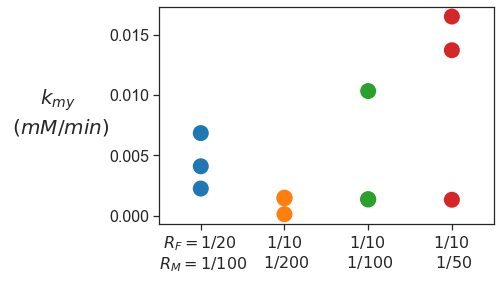

In [19]:
# Perform t-tests on simulation results

# # Make the seaborne boxplot for max energy consumption

# Set palette for boxplot
sns.set_theme(style="ticks", palette="tab10")

#pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$')]

pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/200$'),
              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$'),
              ('$1/10$ \n $1/200$','$1/10$ \n $1/100$'),
              ('$1/10$ \n $1/200$','$1/10$ \n $1/50$'),
              ('$1/10$ \n $1/100$','$1/10$ \n $1/50$')]

# Draw a nested boxplot
ax = sns.stripplot(data=kmy_TTest,jitter=False,s=16)

# Create t-test annotations
#annotator = Annotator(ax, pairs, data=kmy_TTest)
#annotator.configure(test="t-test_ind")
#annotator.apply_and_annotate()

#ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
plt.ylabel("$k_{my}$ \n $(mM/min)$",fontsize=20,rotation=0)
#plt.xlabel("Conditions",fontsize=ftsz)
plt.tick_params(axis='both', which='major', labelsize=16)
ax.yaxis.set_label_coords(-0.3,0.4)

plt.savefig('ProcessingStrainRate_Files\\Graphs\\TTest_kmy_Sim.png',bbox_inches='tight')
plt.show()
#sns.despine(offset=10, trim=True)

In [20]:
# Create dataset of catalytic rate that matches the experiment conditions.
CR_plot = pd.DataFrame({'$R_F= 1/20$ \n $R_M = 1/100$': pd.Series(list(catalytic_rate[i] for i in [3,4,5])), 
                          '$1/10$ \n $1/200$': pd.Series(list(catalytic_rate[i] for i in [1,6,11])), 
                               '$1/10$ \n $1/100$': pd.Series(list(catalytic_rate[i] for i in [2,7,10])),
                          '$1/10$ \n $1/50$': pd.Series(list(catalytic_rate[i] for i in [0,8,9]))})


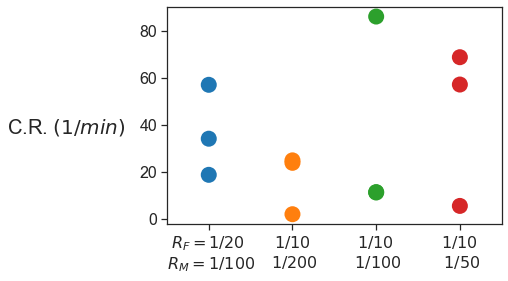

In [21]:
# Get catalytic rate graph

# # Make the seaborne boxplot for max energy consumption

# Set palette for boxplot
sns.set_theme(style="ticks", palette="tab10")

#pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$')]

pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/200$'),
              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$'),
              ('$1/10$ \n $1/200$','$1/10$ \n $1/100$'),
              ('$1/10$ \n $1/200$','$1/10$ \n $1/50$'),
              ('$1/10$ \n $1/100$','$1/10$ \n $1/50$')]

# Draw a nested boxplot
ax = sns.stripplot(data=CR_plot,jitter=False,s=16)

# Create t-test annotations
#annotator = Annotator(ax, pairs, data=kmy_TTest)
#annotator.configure(test="t-test_ind")
#annotator.apply_and_annotate()

#ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
plt.ylabel("C.R. $(1/min)$",fontsize=20,rotation=0)
#plt.xlabel("Conditions",fontsize=ftsz)
plt.tick_params(axis='both', which='major', labelsize=16)
ax.yaxis.set_label_coords(-0.3,0.4)

plt.savefig('ProcessingStrainRate_Files\\Graphs\\CatalyticRate.png',bbox_inches='tight')
plt.show()
#sns.despine(offset=10, trim=True)

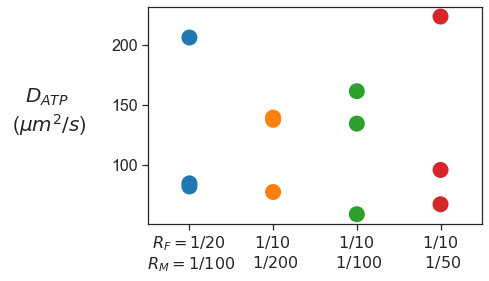

In [5]:
# Perform t-tests on simulation results

# # Make the plot for Diffusion t-test

# Set palette for boxplot
sns.set_theme(style="ticks", palette="tab10")

#pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
#              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$')]

pairs = [('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/200$'),
              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/100$'),
              ('$R_F= 1/20$ \n $R_M = 1/100$','$1/10$ \n $1/50$'),
              ('$1/10$ \n $1/200$','$1/10$ \n $1/100$'),
              ('$1/10$ \n $1/200$','$1/10$ \n $1/50$'),
              ('$1/10$ \n $1/100$','$1/10$ \n $1/50$')]

# Draw a nested boxplot
ax = sns.stripplot(data=Diff_TTest,jitter=False,s=16)

# Create t-test annotations
annotator = Annotator(ax, pairs, data=Diff_TTest)
annotator.configure(test="t-test_ind")
#annotator.apply_and_annotate()

#ax.set(ylabel="$\mathrm{MAX}\; e \: \: (J)$", xlabel="[Myosin] (μM)")
plt.ylabel("$D_{ATP}$ \n ($\mu m^2/s$)",fontsize=20,rotation=0)
#plt.xlabel("Conditions",fontsize=ftsz)
plt.tick_params(axis='both', which='major', labelsize=16)
ax.yaxis.set_label_coords(-0.3,0.4)

plt.savefig('ProcessingStrainRate_Files\\Graphs\\TTest_Diff_Sim.png',bbox_inches='tight')
plt.show()
#sns.despine(offset=10, trim=True)

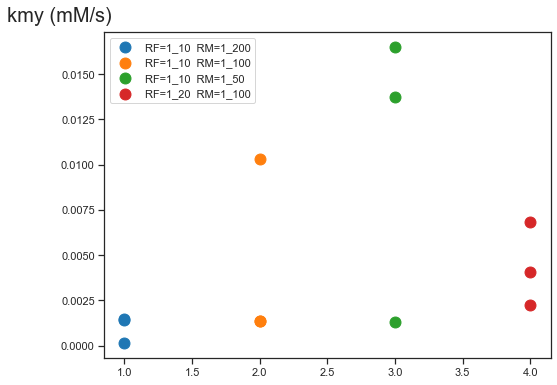

In [6]:
from operator import itemgetter

# Plot the results of my data
kmy_result = [0.0013165274170419128, 0.001491050522094639, 0.001362683705508072, 0.004087037028677409, 0.006837348404687527, 
      0.002244136067481195, 0.0014282037724002716, 0.010320089042819447, 0.013701627679458817, 0.016491178626356184, 
      0.0013430940923084833, 0.00011723981525602056]

D_result = [95.48825528366228, 137.38858248492636, 161.26301525526256, 84.299068008207, 81.70746657749527, 206.07926426555423, 
     77.10989720963045, 134.19552029608442, 
     66.83111355341607, 223.58249258644562, 58.543961145226326, 139.18696870313545]

d_result = [x*(starter_ratio**2) for x in D_result]

List_Sheets = ['RF=1_10  RM=1_50','RF=1_10  RM=1_200',
                'RF=1_10  RM=1_100','RF=1_20  RM=1_100',
                'RF=1_20  RM=1_100','RF=1_20  RM=1_100',
                'RF=1_10  RM=1_200','RF=1_10  RM=1_100',
                'RF=1_10  RM=1_50','RF=1_10  RM=1_50',
               'RF=1_10  RM=1_100','RF=1_10  RM=1_200']

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)

# Make plot of actomyosin activity constants.

plt.ylabel('kmy (mM/s)',fontsize=20,rotation=0)
ax1.yaxis.set_label_coords(-0.1,1.02)
# Plot different conditions at in different bins
ax1.scatter((1,1,1),itemgetter(1,6,11)(kmy_result),s=120,label="RF=1_10  RM=1_200") # 
ax1.scatter((2,2,2),itemgetter(2,7,10)(kmy_result),s=120,label="RF=1_10  RM=1_100") #
ax1.scatter((3,3,3),itemgetter(0,8,9)(kmy_result),s=120,label="RF=1_10  RM=1_50") # 
ax1.scatter((4,4,4),itemgetter(3,4,5)(kmy_result),s=120,label="RF=1_20  RM=1_100") # 
plt.legend(loc='upper left')
plt.show()


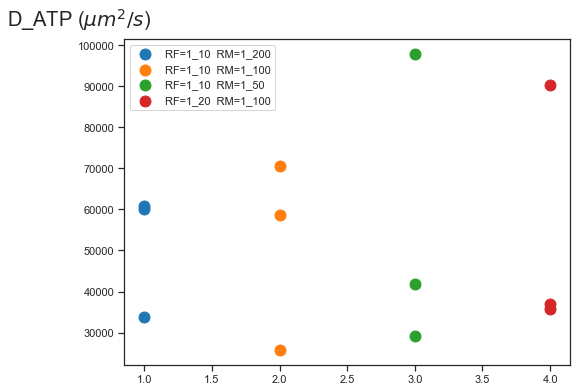

In [7]:
# Make plot of diffusion constants

fig = plt.figure(figsize=(8,6))
ax1 = fig.add_subplot(111)

plt.ylabel('D_ATP ($\mu m^2/s$)',fontsize=20,rotation=0)
ax1.yaxis.set_label_coords(-0.1,1.02)
# Plot different conditions at particular spaces
ax1.scatter((1,1,1),itemgetter(1,6,11)(d_result),s=120,label="RF=1_10  RM=1_200") # 
ax1.scatter((2,2,2),itemgetter(2,7,10)(d_result),s=120,label="RF=1_10  RM=1_100") #
ax1.scatter((3,3,3),itemgetter(0,8,9)(d_result),s=120,label="RF=1_10  RM=1_50") # 
ax1.scatter((4,4,4),itemgetter(3,4,5)(d_result),s=120,label="RF=1_20  RM=1_100") # 
plt.legend(loc='upper left')
plt.show()


In [8]:
# Get average myosin activity ratio and standard deviation of myosin activity ratio for each experimental condition.

RM200_kmy = np.mean(itemgetter(1,6,11)(kmy_result))
RM200_kmy_st = np.std(itemgetter(1,6,11)(kmy_result))

RM100_RF10_kmy = np.mean(itemgetter(2,7,10)(kmy_result))
RM100_RF10_kmy_st = np.std(itemgetter(2,7,10)(kmy_result))

RM50_RF10_kmy = np.mean(itemgetter(0,8,9)(kmy_result))
RM50_RF10_kmy_st = np.std(itemgetter(0,8,9)(kmy_result))

RM100_RF20_kmy = np.mean(itemgetter(3,4,5)(kmy_result))
RM100_RF20_kmy_st = np.std(itemgetter(3,4,5)(kmy_result))
print(RM200_kmy,RM200_kmy_st,RM100_RF10_kmy,RM100_RF10_kmy_st,RM50_RF10_kmy,RM50_RF10_kmy_st,RM100_RF20_kmy,RM100_RF20_kmy_st)

0.0010121647032503105 0.0006333273744546764 0.004341955613545334 0.004227186251861461 0.010503111240952304 0.00659496729264738 0.00438950716694871 0.001887328982464461


In [9]:
# Get average myosin activity ratio for pooled RM100 case

RM100_RF10_kmy = np.mean(itemgetter(2,7,10,3,4,5)(kmy_result))
RM100_RF10_kmy_st = np.std(itemgetter(2,7,10,3,4,5)(kmy_result))

print(RM100_RF10_kmy, RM100_RF10_kmy_st)

0.0043657313902470225 0.003273548905323733


In [10]:
# Get average diffusion constants and standard deviation of diffusion constants for each experimental condition

RM200_D_result = np.mean(itemgetter(1,6,11)(D_result))
RM200_D_result_st = np.std(itemgetter(1,6,11)(D_result))

RM100_RF10_D_result = np.mean(itemgetter(2,7,10)(D_result))
RM100_RF10_D_result_st = np.std(itemgetter(2,7,10)(D_result))

RM50_RF10_D_result = np.mean(itemgetter(0,8,9)(D_result))
RM50_RF10_D_result_st = np.std(itemgetter(0,8,9)(D_result))

RM100_RF20_D_result = np.mean(itemgetter(3,4,5)(D_result))
RM100_RF20_D_result_st = np.std(itemgetter(3,4,5)(D_result))

print(RM200_D_result,RM200_D_result_st,RM100_RF10_D_result,RM100_RF10_D_result_st,
      RM50_RF10_D_result,RM50_RF10_D_result_st,RM100_RF20_D_result,RM100_RF20_D_result_st)

print(np.mean(D_result))
print(np.std(D_result))

117.89514946589742 28.848872299773507 118.0008322321911 43.47031140468358 128.63395380784132 68.15045465820923 124.0285996170855 58.02822747844663
122.13963378075384
51.99657385564526
